# Classification with PyTorch/TensorFlow

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

## Part 1: Iris Classification

Iris Dataset contains 150 records of 3 different classes of irises. Each record contains 4 numeric parameters: sepal length/width and petal length/width. It is an example of a simple dataset, for which you do not need a powerful neural network.

### Getting the Dataset

Iris dataset is build into Scikit Learn, so we can easily get it:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


### Visualize the Data

In many cases, it makes sense to visualize the data to see if they look separable - it would assure us that we should be able to build good classification model. Because we have a few features, we can build a series of pairwise 2D scatter plots, showing different classes by different dot colors. This can be automatically done by a package called **seaborn**:

In [2]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


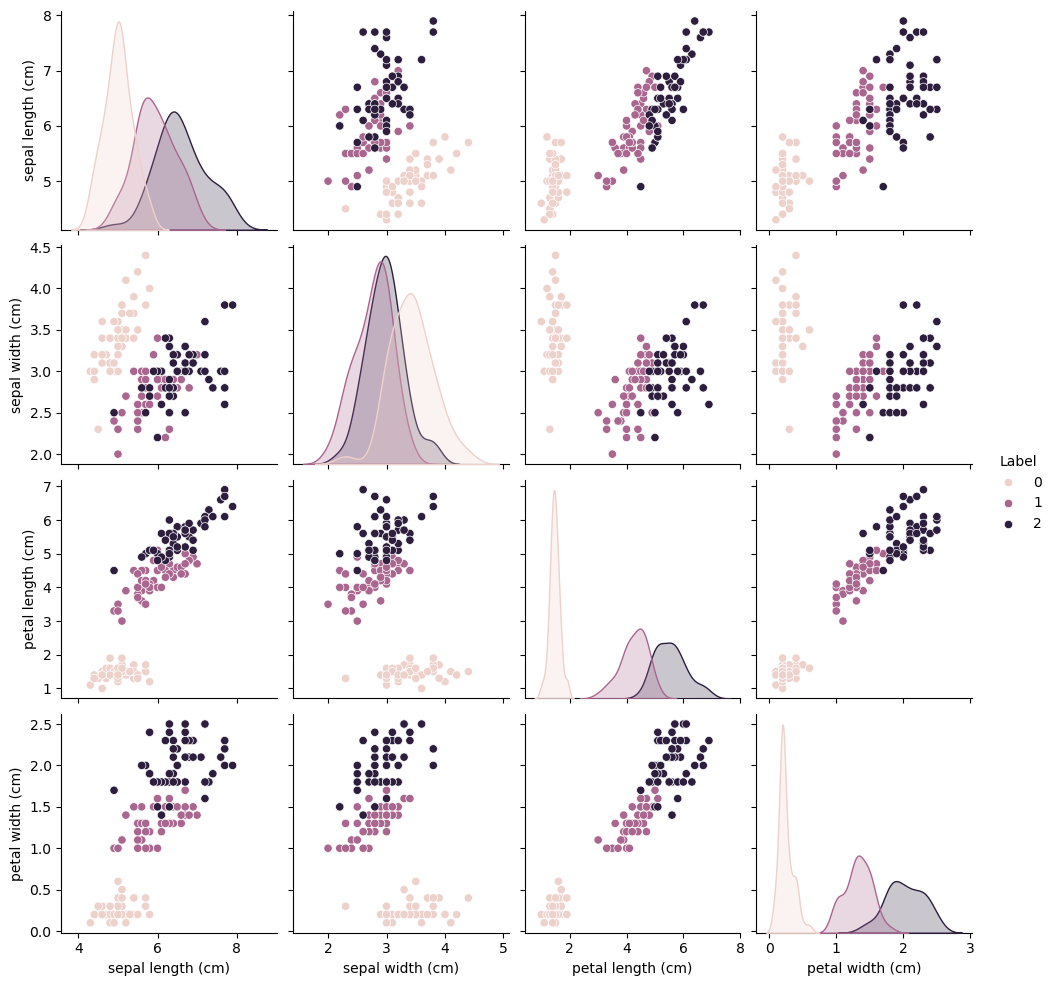

In [3]:
sns.pairplot(df,hue='Label')

### Normalize and Encode the Data

To prepare data to neural network training, we need to normalize inputs in the range [0..1]. This can be done either using plain `numpy` operations, or [Scikit Learn methods](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html).

Also, you need to decide if you want target label to be one-hot encoded or not. PyTorch and TensorFlow allow you feed in class number either as an integer (from 0 to N-1), or as one-hot encoded vector. When creating neural network structure, you need to specify loss function accordingly (eg. *sparse categorical crossentropy* for numeric representation, and *crossentropy loss* for one-hot encoding). One-hot encoding can also be [done using Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), or by using this piece of code:

```python
n_values = np.max(labels) + 1
labels_onehot = np.eye(n_values)[labels]
``` 

In [4]:
# Code to normalize and encode the data
import numpy as np
from sklearn.preprocessing import normalize

# Normalize features to [0, 1] range
features_normalized = (features - features.min(axis=0)) / (features.max(axis=0) - features.min(axis=0))

# One-hot encode labels
n_values = np.max(labels) + 1
labels_onehot = np.eye(n_values)[labels]

print(f"Normalized features shape: {features_normalized.shape}")
print(f"One-hot encoded labels shape: {labels_onehot.shape}")
print(f"Features range: [{features_normalized.min():.2f}, {features_normalized.max():.2f}]")

Normalized features shape: (150, 4)
One-hot encoded labels shape: (150, 3)
Features range: [0.00, 1.00]


### Split the Data into Train and Test

Since we do not have separate train and test dataset, we need to split it intro train and test dataset [using Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    features_normalized, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Classes distribution in train: {np.bincount(y_train)}")
print(f"Classes distribution in test: {np.bincount(y_test)}")

Training set: 120 samples
Test set: 30 samples
Classes distribution in train: [40 40 40]
Classes distribution in test: [10 10 10]


### Define and Train Neural Network

Now you are ready to go, import your preferred framework, define the neural network and start training, observing the behavior of train and validation accuracy.

In [6]:
# Define the network
import torch
import torch.nn as nn
import torch.optim as optim

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Define a simple neural network
class IrisNet(nn.Module):
    def __init__(self, hidden_size=10):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 3)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create model, loss function, and optimizer
model = IrisNet(hidden_size=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

IrisNet(
  (fc1): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)


In [7]:
# Train the network
train_losses = []
train_accuracies = []
test_accuracies = []
epochs = 100

for epoch in range(epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Calculate accuracies
    model.eval()
    with torch.no_grad():
        # Train accuracy
        train_pred = torch.argmax(outputs, dim=1)
        train_acc = (train_pred == y_train_tensor).float().mean().item()
        
        # Test accuracy
        test_outputs = model(X_test_tensor)
        test_pred = torch.argmax(test_outputs, dim=1)
        test_acc = (test_pred == y_test_tensor).float().mean().item()
    
    train_losses.append(loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

print(f'\nFinal Test Accuracy: {test_accuracies[-1]:.4f}')

Epoch [20/100], Loss: 0.9592, Train Acc: 0.7917, Test Acc: 0.7667
Epoch [40/100], Loss: 0.6249, Train Acc: 0.8250, Test Acc: 0.8000
Epoch [60/100], Loss: 0.4131, Train Acc: 0.8833, Test Acc: 0.8000
Epoch [80/100], Loss: 0.3252, Train Acc: 0.9167, Test Acc: 0.8667
Epoch [100/100], Loss: 0.2669, Train Acc: 0.9417, Test Acc: 0.9667

Final Test Accuracy: 0.9667


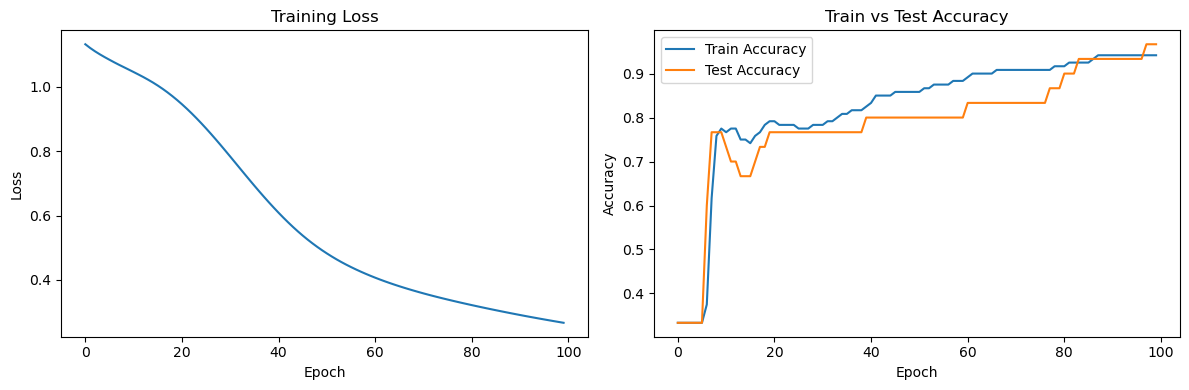

In [8]:
# Visualize train/validation accuracy graph
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

# Plot accuracy
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(test_accuracies, label='Test Accuracy')
ax2.set_title('Train vs Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### Experiment

Now you can experiment with different network architectures to see how it affects the result. Try:
1. One-layer network with 3 neurons (equal to the number of classes)
1. Two-layer network with small/medium/large hidden layer
1. Using more layers

Make sure you observe overfitting when you are using rich model with lots of neurons (parameters).

1-Layer (3 neurons): Final Test Acc = 0.7333
2-Layer (small: 5): Final Test Acc = 0.9667
2-Layer (medium: 10): Final Test Acc = 0.9667
2-Layer (large: 50): Final Test Acc = 1.0000
Deep Network (64-32-16): Final Test Acc = 1.0000


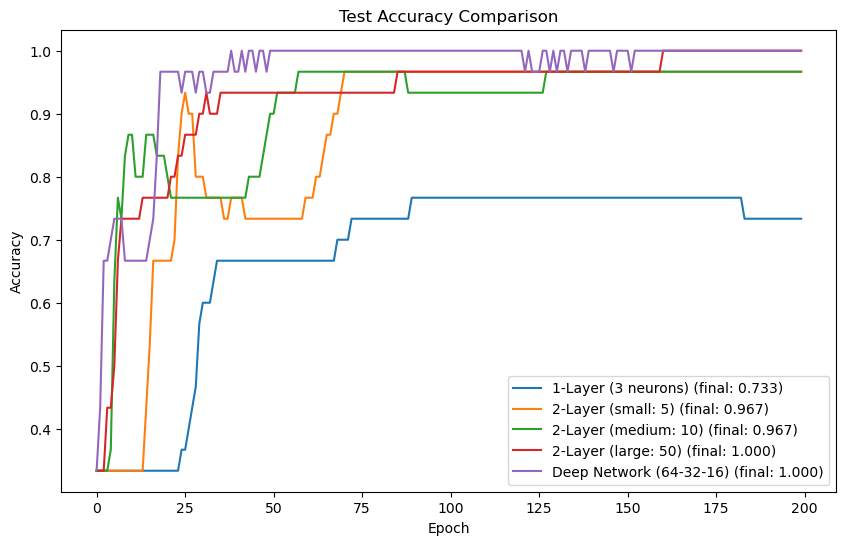

In [9]:
# Experiment with different architectures
def train_and_evaluate(model, epochs=200, verbose=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            train_pred = torch.argmax(outputs, dim=1)
            train_acc = (train_pred == y_train_tensor).float().mean().item()
            
            test_outputs = model(X_test_tensor)
            test_pred = torch.argmax(test_outputs, dim=1)
            test_acc = (test_pred == y_test_tensor).float().mean().item()
        
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    
    return train_accs, test_accs

# 1. One-layer network (no hidden layer, just output)
class OneLayerNet(nn.Module):
    def __init__(self):
        super(OneLayerNet, self).__init__()
        self.fc = nn.Linear(4, 3)
    
    def forward(self, x):
        return self.fc(x)

# 2. Two-layer networks with different hidden sizes
class TwoLayerNet(nn.Module):
    def __init__(self, hidden_size):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(4, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 3)
    
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# 3. Deep network
class DeepNet(nn.Module):
    def __init__(self):
        super(DeepNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
    
    def forward(self, x):
        return self.network(x)

# Train all models
models = {
    '1-Layer (3 neurons)': OneLayerNet(),
    '2-Layer (small: 5)': TwoLayerNet(5),
    '2-Layer (medium: 10)': TwoLayerNet(10),
    '2-Layer (large: 50)': TwoLayerNet(50),
    'Deep Network (64-32-16)': DeepNet()
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    train_accs, test_accs = train_and_evaluate(model)
    plt.plot(test_accs, label=f'{name} (final: {test_accs[-1]:.3f})')
    print(f'{name}: Final Test Acc = {test_accs[-1]:.4f}')

plt.title('Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

## Part 2: MNIST Training

Both Keras and PyTorch contain MNIST as built-in dataset, so you can easily get it with a couple of lines of code ([Keras](https://keras.io/api/datasets/mnist/), [PyTorch](https://pytorch.org/vision/stable/datasets.html)). You will also be able to load both train and test datasets without manually splitting them.

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


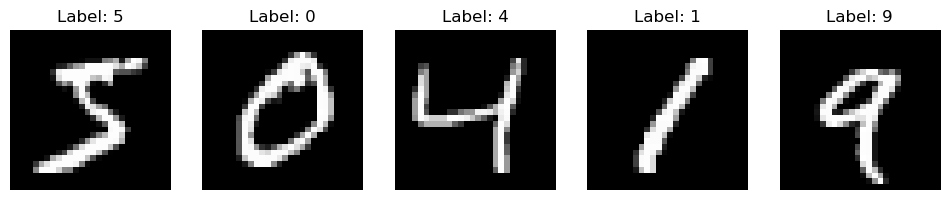

In [10]:
# Load the MNIST dataset
import torchvision
import torchvision.transforms as transforms

# Transform to normalize data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

# Visualize some samples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.show()

### Define Neural Network for MNIST

In [11]:
# Define MNIST Neural Network
class MNISTNet(nn.Module):
    def __init__(self, hidden_size=128):
        super(MNISTNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Create model
mnist_model = MNISTNet(hidden_size=128)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)

print(mnist_model)
print(f"Total parameters: {sum(p.numel() for p in mnist_model.parameters()):,}")

MNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total parameters: 101,770


### Train the MNIST Network

In [12]:
# Train the MNIST network
def train_mnist(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    train_accuracies = []
    test_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        
        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        test_acc = correct / total
        
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')
    
    return train_losses, train_accuracies, test_accuracies

# Train the model
mnist_model = MNISTNet(hidden_size=128)
train_losses, train_accs, test_accs = train_mnist(mnist_model, train_loader, test_loader, epochs=10)

Epoch [1/10], Loss: 0.2551, Train Acc: 0.9261, Test Acc: 0.9616
Epoch [2/10], Loss: 0.1130, Train Acc: 0.9663, Test Acc: 0.9717
Epoch [3/10], Loss: 0.0792, Train Acc: 0.9757, Test Acc: 0.9745
Epoch [4/10], Loss: 0.0594, Train Acc: 0.9814, Test Acc: 0.9744
Epoch [5/10], Loss: 0.0484, Train Acc: 0.9846, Test Acc: 0.9767
Epoch [6/10], Loss: 0.0374, Train Acc: 0.9881, Test Acc: 0.9740
Epoch [7/10], Loss: 0.0314, Train Acc: 0.9897, Test Acc: 0.9767
Epoch [8/10], Loss: 0.0276, Train Acc: 0.9909, Test Acc: 0.9775
Epoch [9/10], Loss: 0.0224, Train Acc: 0.9922, Test Acc: 0.9796
Epoch [10/10], Loss: 0.0194, Train Acc: 0.9935, Test Acc: 0.9758


### Visualize Training Results

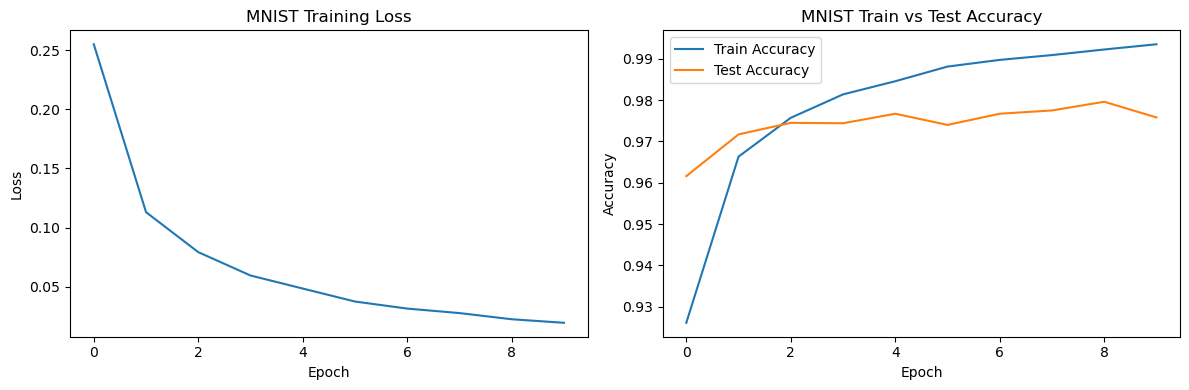

Final Test Accuracy: 0.9758 (97.58%)


In [13]:
# Visualize training results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot loss
ax1.plot(train_losses)
ax1.set_title('MNIST Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

# Plot accuracy
ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(test_accs, label='Test Accuracy')
ax2.set_title('MNIST Train vs Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Final Test Accuracy: {test_accs[-1]:.4f} ({test_accs[-1]*100:.2f}%)")

### Experiment with Different Architectures

Let's compare different network architectures for MNIST classification:
1. Simple linear classifier (no hidden layer)
2. Two-layer networks with different hidden sizes
3. Deep convolutional network (CNN)

In [14]:
# Experiment with different MNIST architectures

# 1. Simple linear classifier
class LinearMNIST(nn.Module):
    def __init__(self):
        super(LinearMNIST, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28 * 28, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

# 2. Two-layer networks
class TwoLayerMNIST(nn.Module):
    def __init__(self, hidden_size):
        super(TwoLayerMNIST, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# 3. CNN for MNIST
class CNNMNIST(nn.Module):
    def __init__(self):
        super(CNNMNIST, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

# Create models
mnist_models = {
    'Linear': LinearMNIST(),
    '2-Layer (32)': TwoLayerMNIST(32),
    '2-Layer (128)': TwoLayerMNIST(128),
    '2-Layer (512)': TwoLayerMNIST(512),
    'CNN': CNNMNIST()
}

print("Model Parameters:")
for name, model in mnist_models.items():
    print(f"  {name}: {count_parameters(model):,} parameters")

Model Parameters:
  Linear: 7,850 parameters
  2-Layer (32): 25,450 parameters
  2-Layer (128): 101,770 parameters
  2-Layer (512): 407,050 parameters
  CNN: 206,922 parameters


Training Linear...
  Linear: Final accuracy = 0.9215
Training 2-Layer (32)...
  2-Layer (32): Final accuracy = 0.9631
Training 2-Layer (128)...
  2-Layer (128): Final accuracy = 0.9753
Training 2-Layer (512)...
  2-Layer (512): Final accuracy = 0.9789
Training CNN...
  CNN: Final accuracy = 0.9856


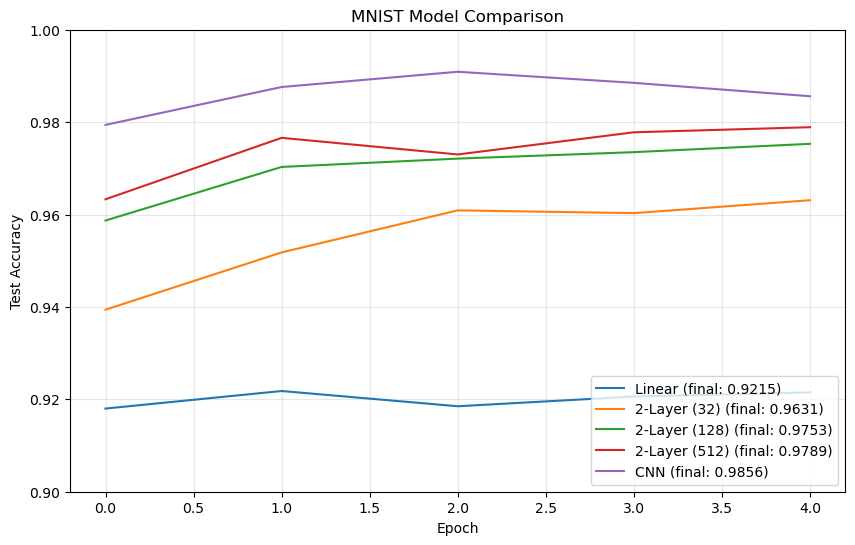

In [15]:
# Train all models and compare
def train_model_quick(model, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    test_accs = []
    
    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
        
        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        test_accs.append(correct / total)
    
    return test_accs

# Train all models
results = {}
plt.figure(figsize=(10, 6))

for name, model in mnist_models.items():
    print(f"Training {name}...")
    accs = train_model_quick(model, train_loader, test_loader, epochs=5)
    results[name] = accs
    plt.plot(accs, label=f'{name} (final: {accs[-1]:.4f})')
    print(f"  {name}: Final accuracy = {accs[-1]:.4f}")

plt.title('MNIST Model Comparison')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend(loc='lower right')
plt.ylim(0.9, 1.0)
plt.grid(True, alpha=0.3)
plt.show()

---

## Summary and Key Takeaways

### What We Learned

This lab covered two classic classification problems using neural networks with PyTorch:

#### Part 1: Iris Classification
- **Dataset**: 150 samples with 4 features, 3 classes
- **Key Steps**:
  1. Data visualization using pair plots to understand feature relationships
  2. Normalization of features to [0, 1] range
  3. Train/test split for proper evaluation
  4. Network architecture experiments

- **Observations**:
  - Even a simple network achieves ~97% accuracy on Iris
  - Over-parameterization can lead to overfitting on small datasets
  - Deep networks are unnecessary for simple classification tasks

#### Part 2: MNIST Digit Classification
- **Dataset**: 60,000 training + 10,000 test images (28x28 grayscale)
- **Key Steps**:
  1. Data loading with built-in PyTorch datasets
  2. Normalization using mean and std deviation
  3. Mini-batch training with DataLoader
  4. Architecture comparison (Linear, MLP, CNN)

- **Observations**:
  - CNNs significantly outperform fully-connected networks for image data
  - Even simple linear classifier achieves ~92% accuracy
  - Hidden layer size affects both accuracy and training speed

### Key Concepts Demonstrated

| Concept | Description |
|---------|-------------|
| **Data Normalization** | Essential for stable training and faster convergence |
| **Train/Test Split** | Critical for detecting overfitting |
| **Architecture Selection** | Match model complexity to problem difficulty |
| **Overfitting** | Occurs when model is too complex for data size |
| **CNNs for Images** | Convolutional layers capture spatial patterns effectively |

### Best Practices

1. **Always visualize your data** before training
2. **Start simple** - begin with a basic model and increase complexity only if needed
3. **Monitor both train and test accuracy** to detect overfitting
4. **Use appropriate architectures** for your data type (CNNs for images, RNNs for sequences)
5. **Normalize input features** to improve training stability

### Next Steps

- Experiment with regularization techniques (Dropout, L2)
- Try different optimizers (SGD with momentum, AdamW)
- Implement early stopping to prevent overfitting
- Explore data augmentation for image datasets
- Try transfer learning with pre-trained models